In [ ]:
# Part 1: Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [6]:
df = pd.read_csv("C:/Users/jyoti/Documents/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

In [9]:
features = [
    'GrLivArea',
    'OverallQual',
    'GarageCars',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'YearBuilt',
]

X = df[features]
y = df['SalePrice']

In [10]:
X = X.fillna(X.median())
print(X.isnull().sum())

GrLivArea      0
OverallQual    0
GarageCars     0
TotalBsmtSF    0
1stFlrSF       0
FullBath       0
YearBuilt      0
dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 7)
Testing data: (292, 7)


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)
print("Predicted House Prices:")
print(y_pred[:10])

Predicted House Prices:
[143488.60431906 294809.32556507 121011.89191238 174550.02625133
 289632.93259786  55778.50480886 211466.82777531 171106.74485155
  55054.02679664 129344.69183385]


In [14]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R^2 Score:", r2)
print("Mean Squared Error:", mse)

R^2 Score: 0.7955277762397561
Mean Squared Error: 1568368656.550029


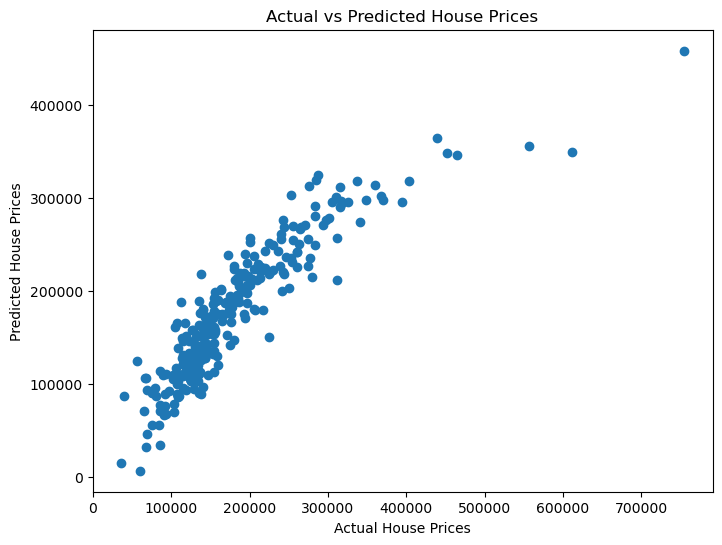

In [15]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
# Part 2: Logistic Regression

In [16]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [17]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
X = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()
y = titanic['survived'].copy()

In [20]:
X['age'] = X['age'].fillna(X['age'].median())
print(X.isnull().sum())

pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64


In [21]:
X = pd.get_dummies(X, columns = ['sex'], drop_first = True)
X.head()

,pclass,age,sibsp,parch,fare,sex_male
0,3,22.0,1,0,7.2500,True
1,1,38.0,1,0,71.2833,False
2,3,26.0,0,0,7.9250,False
3,1,35.0,1,0,53.1000,False
4,3,35.0,0,0,8.0500,True


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


In [24]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)
print("Predicted values:")
print(y_pred[:10])

Predicted values:
[0 0 0 0 1 0 1 0 0 0]


In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [27]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[95 15]
 [20 49]]


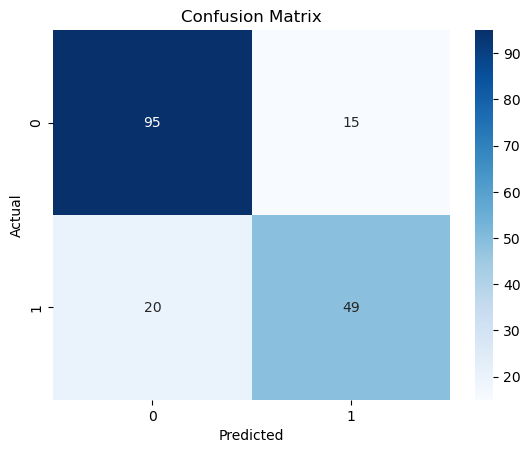

In [28]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Mini Project 2: House Price Prediction

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [32]:
house = pd.read_csv("C:/Users/jyoti/Documents/train.csv")
house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [33]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'YearBuilt',
    'FullBath',
    '1stFlrSF'
]
X = house[features].copy()
y = house['SalePrice'].copy()

In [34]:
X = X.fillna(X.median())

print("Missing values:")
print(X.isnull().sum())

Missing values:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
YearBuilt      0
FullBath       0
1stFlrSF       0
dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1168
Testing samples: 292


In [36]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [37]:
y_pred = model.predict(X_test)
print("Predicted prices:")
print(y_pred[: 10])

Predicted prices:
[143488.60431906 294809.32556506 121011.89191238 174550.02625133
 289632.93259786  55778.50480887 211466.8277753  171106.74485155
  55054.02679665 129344.69183385]


In [38]:
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

R^2 Score: 0.795527776239753


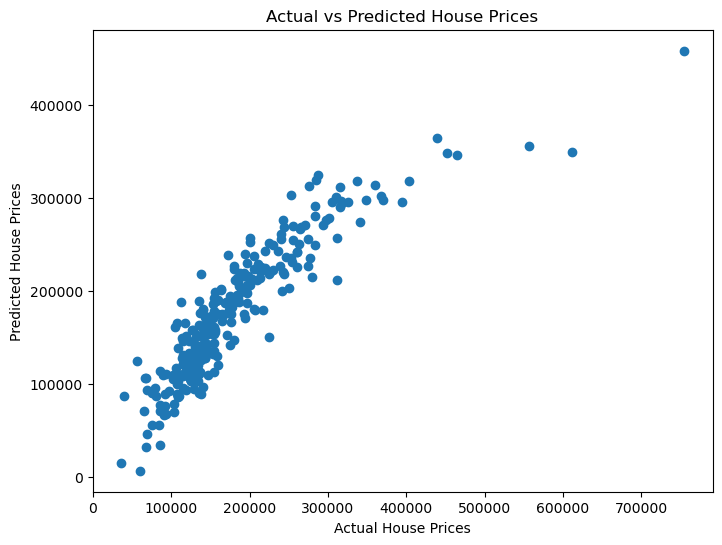

In [39]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Conclusion

A Linear Regression model was developed to predict house prices using selected features from the House Prices Dataset.
The model was evaluated using the R^2 Score. The Actual vs Predicted plot was also used to compare the predicted house prices
with their actual values.